In [39]:
import pandas as pd
import seaborn as sns 

In [5]:
house_data=pd.read_csv("HousePricePrediction (1).csv")

In [6]:
house_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [8]:
house_data.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [11]:
print(house_data.info())
print(house_data.shape)
print(house_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None
(2919, 13)
                Id   MSSubClass        LotArea  OverallCond    YearBuilt  \
count  2919.000000  2919.000000    2919.000000  2919.000000  2919.000000   
mean   1459.0000

In [18]:
#DATA CLEANING
house_data.drop(['Id'],axis=1,inplace=True,errors='ignore')

#Replacing SalePrice empty values with thier mean values 
house_data['SalePrice']=house_data['SalePrice'].fillna(house_data['SalePrice'].mean())

#Drop records with null values
house_data=house_data.dropna()
house_data.isnull().sum()
house_data.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [20]:
print(house_data.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
2914    False
2915    False
2916    False
2917    False
2918    False
Length: 2913, dtype: bool


In [23]:
#DATA PREPROCESSING - Encoding 
cols=['MSZoning','LotConfig','BldgType','Exterior1st']
house_data=pd.get_dummies(house_data,columns=cols,drop_first=True)



In [26]:
from sklearn.model_selection import train_test_split

x=house_data.drop(['SalePrice'],axis=1)
y=house_data['SalePrice']
x_train,x_test,y_train,y_test=train_test_split(
x,y,test_size=0.2,random_state=0)

In [27]:
x_train.head()


,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1453,20,17217,5,2006,2006,0.0,1140.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2021,20,19508,5,1974,1974,0.0,1430.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
188,90,7018,5,1979,1979,0.0,1086.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1273,80,11512,7,1959,2006,0.0,1019.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1960,20,7560,5,1971,1971,613.0,864.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [28]:
#Train the model

from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
y_pred=model.predict(x_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print(mean_absolute_percentage_error(y_test,y_pred))

R2 Score: -6362023.237558593
MAE: 125074937.72090627
RMSE: 131162259.64668839
727.5448669388054


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [35]:
#Model Evaluation
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

model=LinearRegression()
model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)

print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print(mean_absolute_percentage_error(y_test,y_pred))

R2 Score: 0.3741421796138532
MAE: 30829.936664321864
RMSE: 41138.55870230105
0.18742025463427794


In [42]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


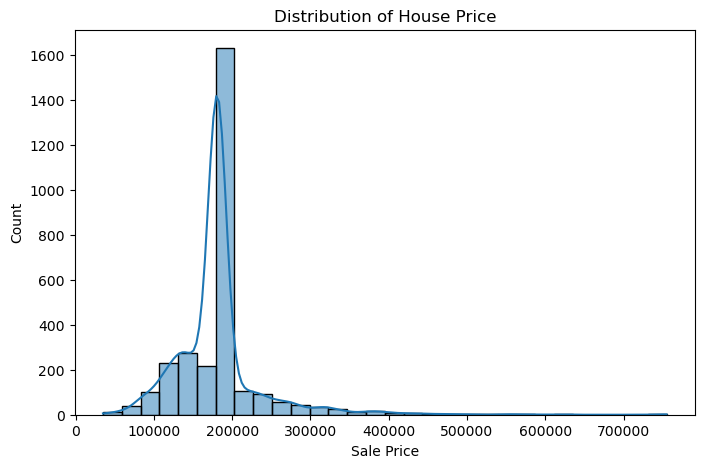

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(house_data['SalePrice'],bins=30,kde=True)
plt.title("Distribution of House Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

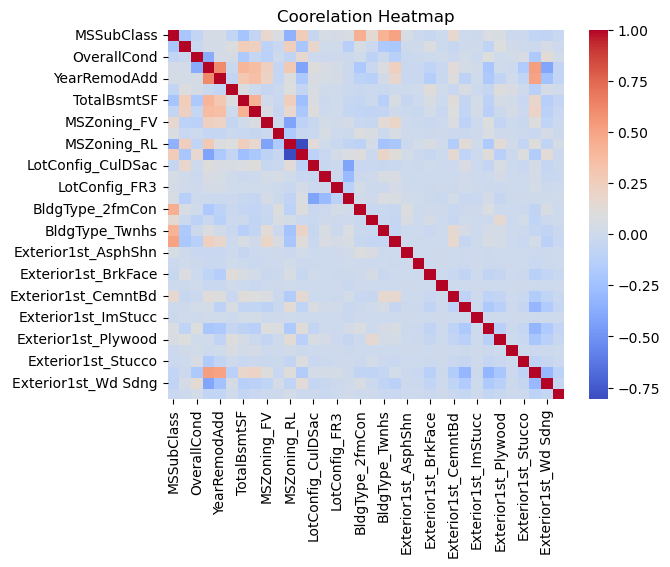

In [46]:
sns.heatmap(house_data.corr(),annot=False,cmap='coolwarm')
plt.title("Coorelation Heatmap")
plt.show()

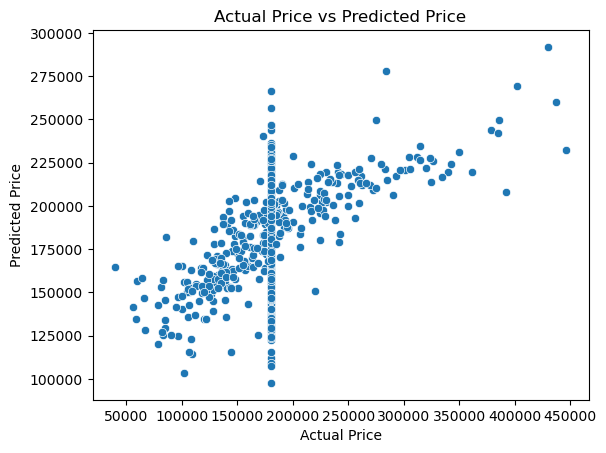

In [57]:
sns.scatterplot(x=y_test,y=y_pred)
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()